
# Assignment 1 - Part 1: Data Preprocessing & EDA
### POS Tagging using Hidden Markov Models (HMMs)

This notebook implements **Part 1** of the assignment:

1. Data Loading
2. Exploratory Data Analysis (EDA)
3. Vocabulary Handling & Unknown Words
4. Sentence Padding
5. Data Splitting

Dataset:
- Training Category: Brown Corpus `news`
- Testing Category: Brown Corpus `fiction`


In [2]:

# Install/download resources (run once)

import sys
import nltk

nltk.download('brown')
nltk.download('universal_tagset')


[nltk_data] Downloading package brown to
[nltk_data]     C:\Users\priya\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\brown.zip.
[nltk_data] Downloading package universal_tagset to
[nltk_data]     C:\Users\priya\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\universal_tagset.zip.


True


## 1. Data Loading

We load tagged sentences from the Brown corpus.

- Training data = `news`
- Testing data = `fiction`

Universal POS tags are used because they are easier to analyze.


In [3]:

from nltk.corpus import brown

train_sentences = brown.tagged_sents(
    categories='news',
    tagset='universal'
)

test_sentences = brown.tagged_sents(
    categories='fiction',
    tagset='universal'
)

print("Training sentences:", len(train_sentences))
print("Testing sentences :", len(test_sentences))

print("\nSample training sentence:")
print(train_sentences[0][:10])


Training sentences: 4623
Testing sentences : 4249

Sample training sentence:
[('The', 'DET'), ('Fulton', 'NOUN'), ('County', 'NOUN'), ('Grand', 'ADJ'), ('Jury', 'NOUN'), ('said', 'VERB'), ('Friday', 'NOUN'), ('an', 'DET'), ('investigation', 'NOUN'), ('of', 'ADP')]



## 2. Exploratory Data Analysis (EDA)

We will:

- Count total words
- Count unique words
- Count POS tags
- Plot POS tag distribution


In [4]:

from collections import Counter

word_counter = Counter()
tag_counter = Counter()

for sent in train_sentences:
    for word, tag in sent:
        word_counter[word.lower()] += 1
        tag_counter[tag] += 1

print("Total tokens      :", sum(word_counter.values()))
print("Unique vocabulary :", len(word_counter))
print("Number of POS tags:", len(tag_counter))


Total tokens      : 100554
Unique vocabulary : 13112
Number of POS tags: 12


In [5]:

import pandas as pd

tag_df = pd.DataFrame(
    tag_counter.items(),
    columns=['POS_Tag', 'Count']
).sort_values('Count', ascending=False)

tag_df.head(15)


,POS_Tag,Count
1,NOUN,30654
3,VERB,14399
4,ADP,12355
5,.,11928
0,DET,11389
2,ADJ,6706
6,ADV,3349
7,CONJ,2717
9,PRON,2535
8,PRT,2264


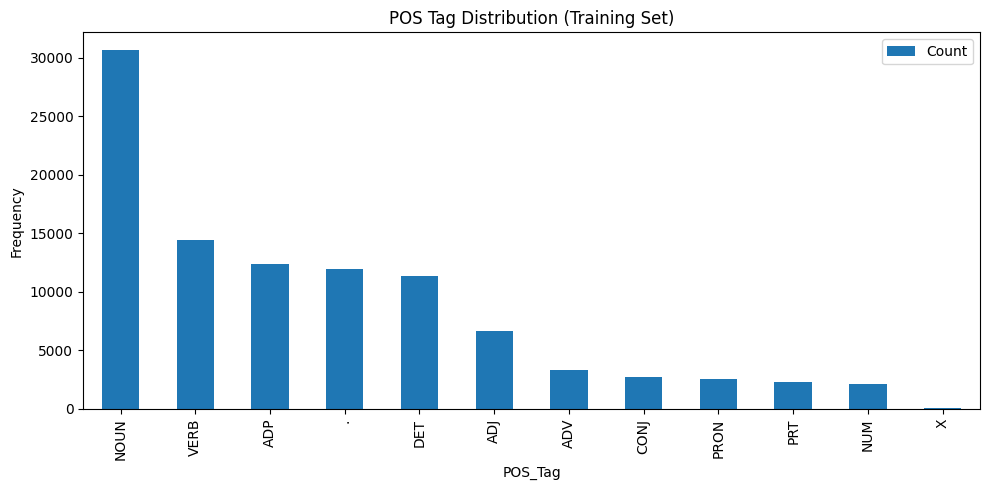

In [6]:

import matplotlib.pyplot as plt

tag_df.plot(
    x='POS_Tag',
    y='Count',
    kind='bar',
    figsize=(10,5)
)

plt.title("POS Tag Distribution (Training Set)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()



### Most Frequent Words
Useful for understanding corpus characteristics.


In [7]:

pd.DataFrame(
    word_counter.most_common(20),
    columns=['Word','Frequency']
)


,Word,Frequency
0,the,6386
1,",",5188
2,.,4030
3,of,2861
4,and,2186
5,to,2144
6,a,2130
7,in,2020
8,for,969
9,that,829



## 3. Vocabulary Handling & Unknown Words

HMMs struggle with words never seen during training.

Strategy:

- Build vocabulary from training set.
- Words occurring fewer than a threshold are replaced by `<UNK>`.
- Any unseen test word is mapped to `<UNK>`.


In [8]:

UNK_THRESHOLD = 1

vocab = {
    word
    for word, freq in word_counter.items()
    if freq > UNK_THRESHOLD
}

print("Vocabulary size after thresholding:", len(vocab))


Vocabulary size after thresholding: 6278


In [9]:

def replace_rare_words(sentence, vocabulary):
    processed = []

    for word, tag in sentence:
        word = word.lower()

        if word not in vocabulary:
            word = "<UNK>"

        processed.append((word, tag))

    return processed

train_processed = [
    replace_rare_words(sent, vocab)
    for sent in train_sentences
]

test_processed = [
    replace_rare_words(sent, vocab)
    for sent in test_sentences
]

print(train_processed[0][:10])


[('the', 'DET'), ('fulton', 'NOUN'), ('county', 'NOUN'), ('grand', 'ADJ'), ('jury', 'NOUN'), ('said', 'VERB'), ('friday', 'NOUN'), ('an', 'DET'), ('investigation', 'NOUN'), ('of', 'ADP')]



## 4. Sentence Padding

Padding helps estimate transition probabilities correctly.

We add:

- `<START>` tag at beginning
- `<END>` tag at end


In [10]:

START_TOKEN = "<START>"
END_TOKEN = "<END>"

def pad_sentence(sentence):

    return (
        [(START_TOKEN, START_TOKEN)]
        + sentence
        + [(END_TOKEN, END_TOKEN)]
    )

train_padded = [pad_sentence(s) for s in train_processed]
test_padded = [pad_sentence(s) for s in test_processed]

print(train_padded[0][:5])
print("...")
print(train_padded[0][-5:])


[('<START>', '<START>'), ('the', 'DET'), ('fulton', 'NOUN'), ('county', 'NOUN'), ('grand', 'ADJ')]
...
[('irregularities', 'NOUN'), ('took', 'VERB'), ('place', 'NOUN'), ('.', '.'), ('<END>', '<END>')]



## 5. Data Splitting

The assignment already specifies:

- Training = Brown `news`
- Testing = Brown `fiction`

Let's verify sizes.


In [11]:

print("Training Sentences:", len(train_padded))
print("Testing Sentences :", len(test_padded))

train_tokens = sum(len(s) for s in train_padded)
test_tokens = sum(len(s) for s in test_padded)

print("Training Tokens:", train_tokens)
print("Testing Tokens :", test_tokens)


Training Sentences: 4623
Testing Sentences : 4249
Training Tokens: 109800
Testing Tokens : 76986
